# Decision Tree

## Training a Decision Tree with Scikit-Learn Library

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import pandas as pd

In [2]:
from sklearn import tree

In [3]:
X=[[0,0],[1,2]]
y=[0,1]

In [4]:
clf=tree.DecisionTreeClassifier()

In [5]:
clf=clf.fit(X,y)

In [6]:
clf.predict([[2.,2.]])

array([1])

In [7]:
clf.predict_proba([[2.,2.]])

array([[0., 1.]])

In [8]:
clf.predict([[0.4,1.2]])

array([0])

In [9]:
clf.predict_proba([[0.4,1.2]])

array([[1., 0.]])

In [10]:
clf.predict_proba([[0,0.2]])

array([[1., 0.]])

DecisionTreeClassifier is capable of both binary(where the labels are[-1,1]) classification and multiclass(where the labels are[0,....,K-1]) classification

## Applying to Iris Dataset

In [11]:
from sklearn.datasets import load_iris
from sklearn import tree
iris=load_iris()

In [12]:
iris.data[0:5]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

In [13]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [14]:
X=iris.data[:,2:]

In [15]:
y=iris.target
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [16]:
clf=tree.DecisionTreeClassifier(random_state=42)

In [17]:
clf=clf.fit(X,y)

### Export_graphviz
Need to install graphviz first
conda install graphviz python-graphviz

In [18]:
from sklearn.tree import export_graphviz

In [20]:
export_graphviz(clf,
                out_file="tree.dot",
                feature_names=iris.feature_names[2:],
                class_names=iris.target_names,
                rounded=True,
                filled=True)

Run the folloeing line on your command prompt.   
dot -Tpng tree.dot -o tree.png  #not necessary

## Graphviz

In [21]:
import graphviz

In [22]:
dot_data=tree.export_graphviz(clf,out_file=None,
                              feature_names=iris.feature_names[2:],
                              class_names=iris.target_names,
                              rounded=True,
                              filled=True)

In [23]:
graph=graphviz.Source(dot_data)

In [24]:
graph

CalledProcessError: Command '['dot.bat', '-Kdot', '-Tsvg']' returned non-zero exit status 3221225477. [stderr: b'Warning: Could not load "C:\\Users\\ADMIN\\anaconda3\\envs\\ML_Python\\Library\\bin\\gvplugin_pango.dll" - It was found, so perhaps one of its dependents was not.  Try ldd.\r\n']

Dont worry abt above error because it just visualization of tree image  
it just a explaination image

---
## Visualize the Decision Boundary

In [36]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import pandas as pd
sns.set_style('whitegrid')

In [37]:
df=sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [38]:
col=['petal_length','petal_width']
X=df.loc[:,col]

In [44]:
species_to_num={'setosa':0,
                'versicolor':1,
                'vriginica':2}
df['tmp']=df['species'].map(species_to_num)
y=df['tmp']
y = y.fillna(0)

In [45]:
clf=tree.DecisionTreeClassifier()
clf=clf.fit(X,y)

In [47]:
Xv=X.values.reshape(-1,1)
h=0.02
x_min,x_max=Xv.min(),Xv.max()+1
y_min,y_max=y.min(),y.max()+1
xx,yy=np.meshgrid(np.arange(x_min,x_max,h),
                  np.arange(y_min,y_max,h))

C:\Users\ADMIN\anaconda3\envs\ML_Python\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


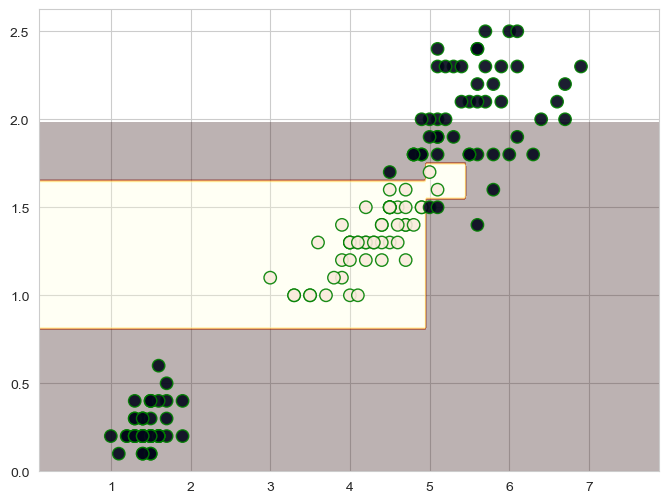

In [48]:
z=clf.predict(np.c_[xx.ravel(),yy.ravel()])
z=z.reshape(xx.shape)
fig=plt.figure(figsize=(8,6))
ax=plt.contourf(xx,yy,z,cmap='afmhot',alpha=0.3)
plt.scatter(X.values[:,0],X.values[:,1],c=y,s=80,
            alpha=0.9,edgecolor='g')

---

### Regression

In [53]:
from sklearn import tree

In [54]:
X=[[0,0],[3,3]]
y=[0.75,3]

In [55]:
tree_reg=tree.DecisionTreeRegressor(random_state=42)

In [56]:
tree_reg=tree_reg.fit(X,y)

In [57]:
tree_reg.predict([[1.5,1.5]])

array([0.75])

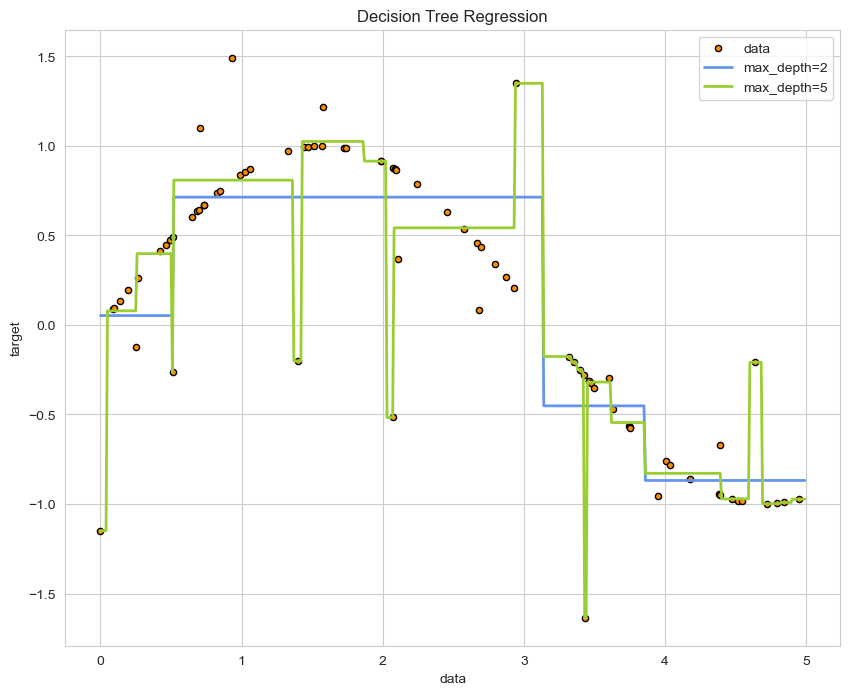

In [59]:
#import neccessary libraries and modeules.
import numpy as np
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt

#create a random dataset
rng=np.random.RandomState(1)
X=np.sort(5*rng.rand(80,1),axis=0)
y=np.sin(X).ravel()
y[::5]+=3*(0.5-rng.rand(16))

#Fit regression model
regr_1=DecisionTreeRegressor(max_depth=2)
regr_2=DecisionTreeRegressor(max_depth=5)
regr_1.fit(X,y)
regr_2.fit(X,y)

#predict
X_test=np.arange(0.0,5.0,0.01)[:,np.newaxis]
y_1=regr_1.predict(X_test)
y_2=regr_2.predict(X_test)

#plot the results
plt.figure(figsize=(10,8))
plt.scatter(X,y,s=20,edgecolor='black',
            c='darkorange',label="data")
plt.plot(X_test,y_1,color="cornflowerblue",
         label="max_depth=2",linewidth=2)
plt.plot(X_test,y_2,color="yellowgreen",
         label="max_depth=5",linewidth=2)
plt.xlabel("data")
plt.ylabel("target")
plt.title("Decision Tree Regression")
plt.legend()
plt.show()

The above figure shows the Over fitting.

## Regularization

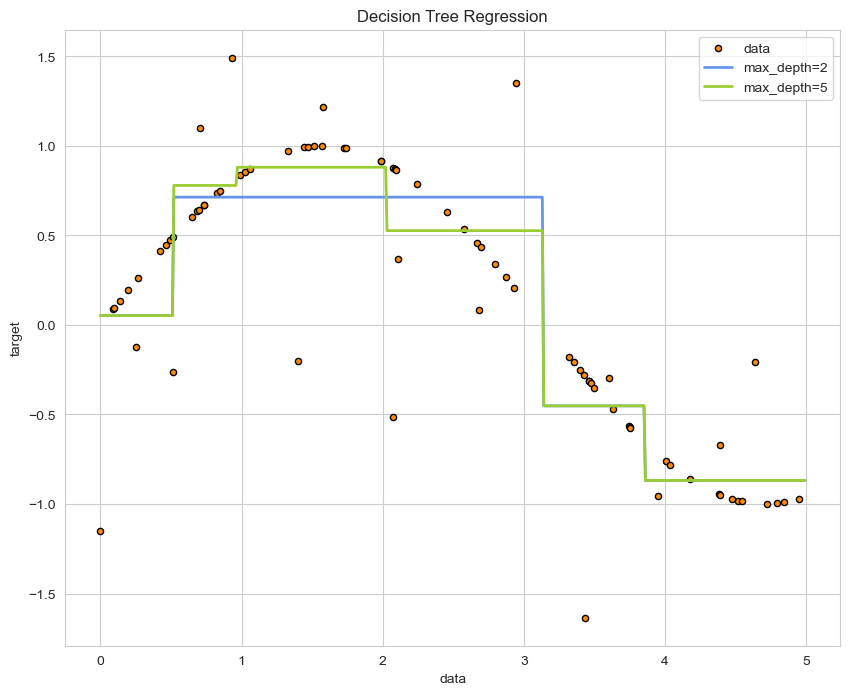

In [60]:
#import neccessary libraries and modeules.
import numpy as np
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt

#create a random dataset
rng=np.random.RandomState(1)
X=np.sort(5*rng.rand(80,1),axis=0)
y=np.sin(X).ravel()
y[::5]+=3*(0.5-rng.rand(16))

#Fit regression model
regr_1=DecisionTreeRegressor(max_depth=2)
regr_2=DecisionTreeRegressor(max_depth=5,min_samples_leaf=10)
regr_1.fit(X,y)
regr_2.fit(X,y)

#predict
X_test=np.arange(0.0,5.0,0.01)[:,np.newaxis]
y_1=regr_1.predict(X_test)
y_2=regr_2.predict(X_test)

#plot the results
plt.figure(figsize=(10,8))
plt.scatter(X,y,s=20,edgecolor='black',
            c='darkorange',label="data")
plt.plot(X_test,y_1,color="cornflowerblue",
         label="max_depth=2",linewidth=2)
plt.plot(X_test,y_2,color="yellowgreen",
         label="max_depth=5",linewidth=2)
plt.xlabel("data")
plt.ylabel("target")
plt.title("Decision Tree Regression")
plt.legend()
plt.show()

## Over fitting

In [61]:
from sklearn.datasets import load_iris
from sklearn import tree
iris=load_iris()

In [62]:
X=iris.data[:,0:2]
y=iris.target
clf=tree.DecisionTreeClassifier(random_state=42)
clf=clf.fit(X,y)

In [63]:
dot_data=tree.export_graphviz(clf,out_file=None,
                              feature_names=iris.feature_names[2:],
                              class_names=iris.target_names,
                              filled=True)

In [64]:
graph=graphviz.Source(dot_data)
graph

CalledProcessError: Command '['dot.bat', '-Kdot', '-Tsvg']' returned non-zero exit status 3221225477. [stderr: b'Warning: Could not load "C:\\Users\\ADMIN\\anaconda3\\envs\\ML_Python\\Library\\bin\\gvplugin_pango.dll" - It was found, so perhaps one of its dependents was not.  Try ldd.\r\n']

As per the above error message we see in the last line that the picture was found but some ldd issue its not displaying.

## Modelling End-to-End with Decision Tree

In [66]:
from sklearn.datasets import make_moons

In [67]:
X_data,y_data=make_moons(n_samples=1000,noise=0.5,random_state=42)

In [68]:
cl1=tree.DecisionTreeClassifier(random_state=42)
cl2=tree.DecisionTreeClassifier(min_samples_leaf=10,random_state=42)

In [69]:
from sklearn.model_selection import train_test_split

In [71]:
X_train,X_test,y_train,y_test =train_test_split(X_data,y_data,test_size=0.1,random_state=42)

In [72]:
from sklearn.model_selection import GridSearchCV

In [73]:
#params={'max_leaf_nodes':list(range(2,50)),
#        'min_samples_split':[2,3,4],
#        'min_samples_leaf':list(range(5,20))}

params={'min_samples_leaf':list(range(2,20))}

In [75]:
grid_search_cv=GridSearchCV(tree.DecisionTreeClassifier(random_state=42),params,n_jobs=-1,verbose=1)
grid_search_cv.fit(X_train,y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'min_samples_leaf': [2, 3, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,None
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [77]:
grid_search_cv.best_estimator_

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,16
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [82]:
from sklearn.tree import DecisionTreeClassifier

In [87]:
DecisionTreeClassifier(class_weight=None,criterion='gini',max_depth=None,
                       max_features=None,max_leaf_nodes=None,
                       min_impurity_decrease=0.0,
                       min_samples_leaf=19,min_samples_split=2,
                       min_weight_fraction_leaf=0.0,
                       random_state=42,splitter='best')

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,19
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [88]:
from sklearn.metrics import accuracy_score

In [89]:
y_pred=grid_search_cv.predict(X_test)
accuracy_score(y_test,y_pred)

0.83

In [91]:
cl1.fit(X_train,y_train)
y_pred=cl1.predict(X_test)
accuracy_score(y_test,y_pred)

0.74

In [92]:
clf.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 42,
 'splitter': 'best'}

In [93]:
cl2.fit(X_train,y_train)
y_pred=cl2.predict(X_test)
accuracy_score(y_test,y_pred)

0.84

---